## Отчет по лабораторной работе: Регрессия и метод главных компонент

### 1 Введение

Цель работы: изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качество.

### 2 Описание датасета

В работе используется набор данных [Computer Hardware из UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/29/computer+hardware). Локальный файл `machine.data` содержит 209 наблюдений и 10 столбцов. Описание исходных полей сохранено в `machine.names`.

Целевая переменная `PRP` — опубликованная относительная производительность компьютера. Хотя значения записаны целыми числами, это количественный показатель, поэтому решаем задачу регрессии. Логистическая регрессия не требуется.

#### 2.1 Загрузка и описание переменных

| Столбец | Описание | Роль в работе |
| :--- | :--- | :--- |
| VendorName | Производитель | Категориальный, исключаем |
| ModelName | Название модели | Идентификатор, исключаем |
| MYCT | Время машинного цикла, нс | Признак |
| MMIN | Минимальная основная память, КБ | Признак |
| MMAX | Максимальная основная память, КБ | Признак |
| CACH | Кэш-память, КБ | Признак |
| CHMIN | Минимальное количество каналов | Признак |
| CHMAX | Максимальное количество каналов | Признак |
| PRP | Опубликованная относительная производительность | Целевая переменная |
| ERP | Оценка производительности из исходной статьи | Исключаем |

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 180)

# Файл доступен при запуске из папки lab1 или из корня проекта
data_path = Path('machine.data')
if not data_path.exists():
    data_path = Path('lab1/machine.data')

columns = ['VendorName', 'ModelName', 'MYCT', 'MMIN', 'MMAX',
           'CACH', 'CHMIN', 'CHMAX', 'PRP', 'ERP']
raw_df = pd.read_csv(data_path, sep=',', header=None, names=columns)

print('Размер датасета:', raw_df.shape)
print(raw_df.head())
raw_df.info()

Размер датасета: (209, 10)
  VendorName ModelName  MYCT  MMIN   MMAX  CACH  CHMIN  CHMAX  PRP  ERP
0    adviser     32/60   125   256   6000   256     16    128  198  199
1     amdahl    470v/7    29  8000  32000    32      8     32  269  253
2     amdahl   470v/7a    29  8000  32000    32      8     32  220  253
3     amdahl   470v/7b    29  8000  32000    32      8     32  172  253
4     amdahl   470v/7c    29  8000  16000    32      8     16  132  132
<class 'pandas.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   VendorName  209 non-null    str  
 1   ModelName   209 non-null    str  
 2   MYCT        209 non-null    int64
 3   MMIN        209 non-null    int64
 4   MMAX        209 non-null    int64
 5   CACH        209 non-null    int64
 6   CHMIN       209 non-null    int64
 7   CHMAX       209 non-null    int64
 8   PRP         209 non-null    int64
 9   ERP         2

В исходной таблице **209 наблюдений и 10 столбцов**: два текстовых и восемь числовых. В файле нет строки заголовков, поэтому названия заданы через `names`, а `header=None` позволяет сохранить первую строку как наблюдение.

Шесть числовых столбцов описывают характеристики компьютеров. `PRP` будем предсказывать, а `ERP` исключим: это уже готовая оценка производительности из исходной статьи, а не характеристика оборудования.

#### 2.2 Описательные статистики и распределения

          MYCT      MMIN      MMAX    CACH   CHMIN   CHMAX      PRP
count   209.00    209.00    209.00  209.00  209.00  209.00   209.00
mean    203.82   2867.98  11796.15   25.21    4.70   18.27   105.62
std     260.26   3878.74  11726.56   40.63    6.82   26.00   160.83
min      17.00     64.00     64.00    0.00    0.00    0.00     6.00
25%      50.00    768.00   4000.00    0.00    1.00    5.00    27.00
50%     110.00   2000.00   8000.00    8.00    2.00    8.00    50.00
75%     225.00   4000.00  16000.00   32.00    6.00   24.00   113.00
max    1500.00  32000.00  64000.00  256.00   52.00  176.00  1150.00

Асимметрия и эксцесс:
       Асимметрия  Эксцесс
MYCT         2.54     7.06
MMIN         3.52    17.61
MMAX         2.14     5.90
CACH         2.82    10.28
CHMIN        4.03    22.47
CHMAX        3.60    15.89
PRP          3.89    19.25


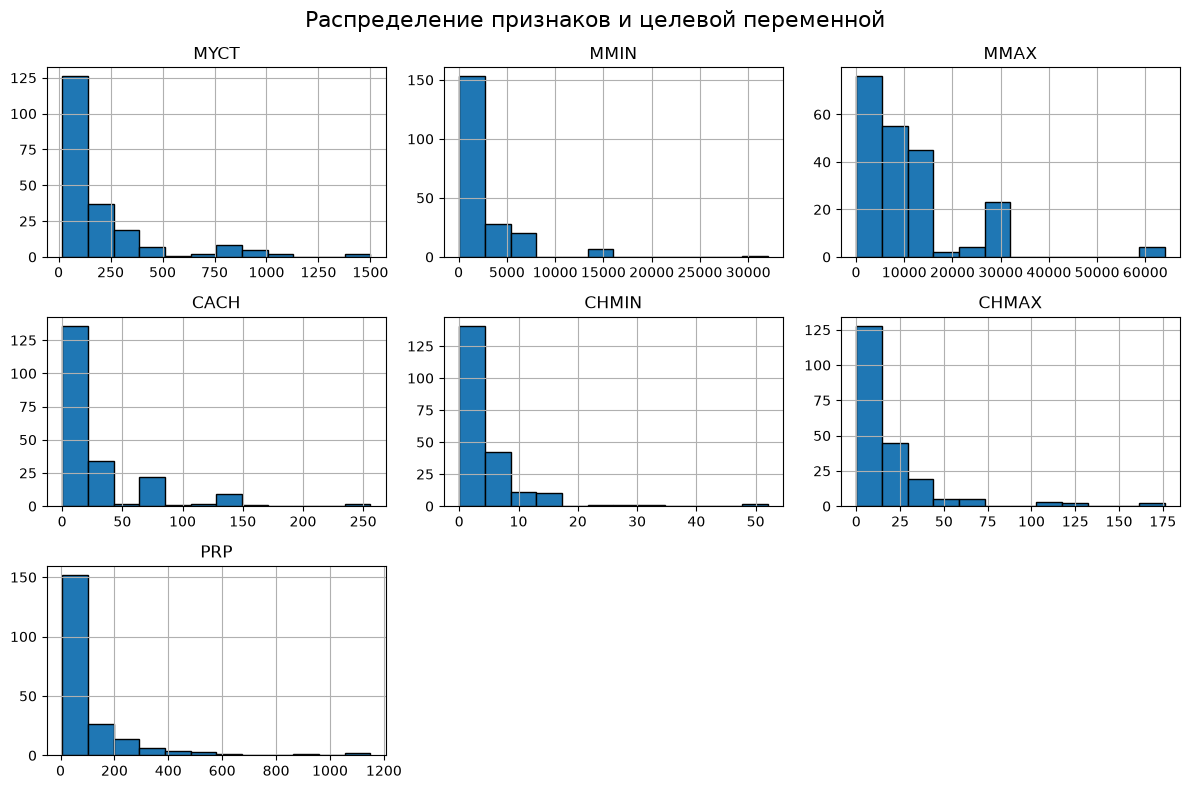

In [2]:
numeric_columns = ['MYCT', 'MMIN', 'MMAX', 'CACH', 'CHMIN', 'CHMAX', 'PRP']
numeric_df = raw_df[numeric_columns]

print(numeric_df.describe().round(2))
print('\nАсимметрия и эксцесс:')
print(pd.DataFrame({
    'Асимметрия': numeric_df.skew(),
    'Эксцесс': numeric_df.kurt()
}).round(2))

numeric_df.hist(bins=12, figsize=(12, 8), edgecolor='black')
plt.suptitle('Распределение признаков и целевой переменной', fontsize=16)
plt.tight_layout()
plt.show()

Как видно по гистограммам, большинство значений сконцентрировано в левой части графиков, следовательно, мы имеем **правую асимметрию**. Это подтверждается положительными значениями асимметрии. Положительный эксцесс указывает на тяжелые хвосты по сравнению с нормальным распределением.

Производительность `PRP` меняется от **6 до 1150**, при этом среднее заметно выше медианы. В выборке много систем небольшой производительности и немного очень мощных. Признаки различаются по масштабу, поэтому перед регуляризацией и PCA потребуется стандартизация.

#### 2.3 Исследование выбросов

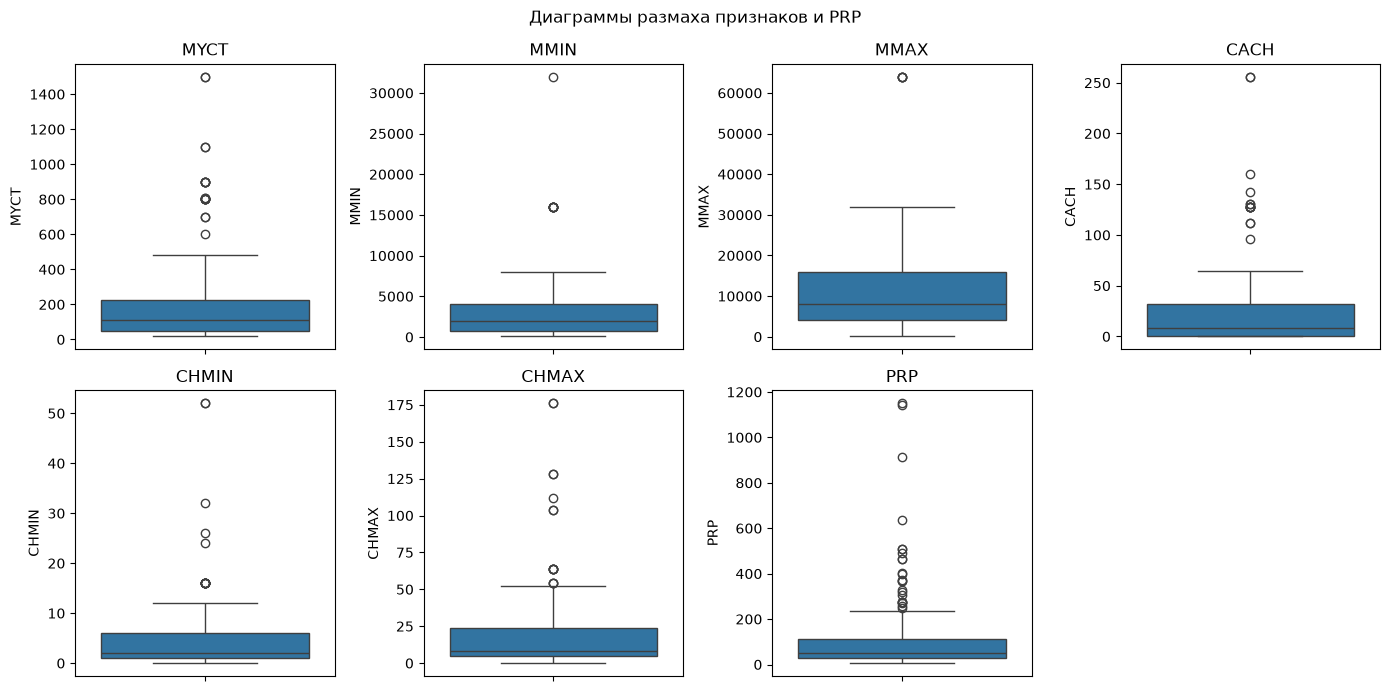

Число значений за границами 1.5 IQR:
MYCT     20
MMIN      8
MMAX      4
CACH     15
CHMIN    15
CHMAX    15
PRP      23
dtype: int64
Строк с хотя бы одним таким значением: 58


In [3]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, column in zip(axes.flat, numeric_columns):
    sns.boxplot(y=numeric_df[column], ax=ax)
    ax.set_title(column)
axes.flat[-1].set_visible(False)
plt.suptitle('Диаграммы размаха признаков и PRP')
plt.tight_layout()
plt.show()

q1 = numeric_df.quantile(0.25)
q3 = numeric_df.quantile(0.75)
iqr = q3 - q1
outlier_mask = (numeric_df < q1 - 1.5 * iqr) | (numeric_df > q3 + 1.5 * iqr)
print('Число значений за границами 1.5 IQR:')
print(outlier_mask.sum())
print('Строк с хотя бы одним таким значением:', outlier_mask.any(axis=1).sum())

На диаграммах размаха видны значения за пределами «усов». Мы дополнительно посчитали их по правилу **1,5 межквартильного размаха (IQR)**. Для `PRP` найдено **23** таких значения, а хотя бы по одному из семи столбцов — **58 строк**. Это статистически необычные значения, но само по себе такое положение не означает ошибку в данных.

**Решение:** наблюдения сохраняем. Большие объемы памяти и высокая производительность могут соответствовать реальным мощным системам; подтверждений ошибок измерения у нас нет. Автоматическое удаление таких строк сократило бы и без того небольшую выборку. Границы IQR здесь нужны только для описания данных и не используются для фильтрации train или test.

#### 2.4 Корреляционная матрица и VIF

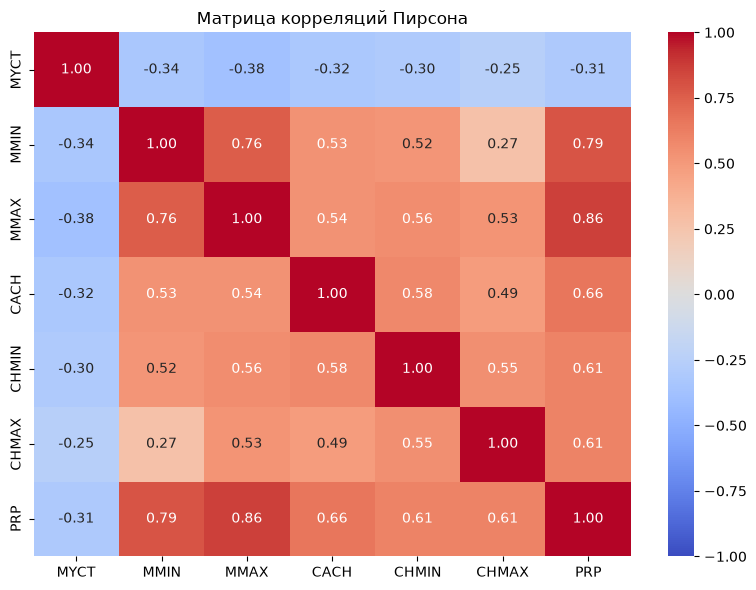

Признак   VIF
   MYCT 1.202
   MMIN 2.902
   MMAX 3.274
   CACH 1.858
  CHMIN 1.966
  CHMAX 1.891


In [4]:
correlation_matrix = numeric_df.corr(method='pearson')
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            vmin=-1, vmax=1)
plt.title('Матрица корреляций Пирсона')
plt.tight_layout()
plt.show()

# Константа нужна для вспомогательных регрессий с обычным свободным членом
X_vif = add_constant(numeric_df.drop(columns=['PRP']).dropna())
vif_data = pd.DataFrame({
    'Признак': X_vif.columns[1:],
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(1, X_vif.shape[1])]
})
print(vif_data.round(3).to_string(index=False))

Как видно из корреляционной матрицы, некоторые признаки связаны друг с другом. Наиболее заметна положительная связь `MMIN` и `MMAX` (около **0,76**): системы с большим минимальным объемом памяти обычно поддерживают и больший максимальный объем. `MYCT` имеет преимущественно отрицательные связи с остальными показателями. Корреляция описывает линейную связь, но не доказывает причинную зависимость.

**По VIF:** значения составляют от **1,20 до 3,27**. Наибольшие значения у `MMAX` (**3,27**) и `MMIN` (**2,90**). Таким образом, взаимосвязи между признаками есть, но **сильная мультиколлинеарность по ориентиру VIF > 5 не подтверждается**. Пороги 5 и 10 являются практическими ориентирами, а не строгим статистическим тестом.

Удалять один из признаков памяти только по этим результатам не будем. В соответствии с заданием исследуем PCA как способ получить некоррелированные признаки и снизить размерность. `PRP` включен в корреляционную матрицу для анализа связи с целью, но исключен из расчета VIF. Константа входит во вспомогательные регрессии VIF, однако ее собственный VIF не интерпретируется.

### 3 Подготовка данных

#### 3.1 Пропуски, дубликаты и выбор признаков

Категориальное кодирование в задании является опциональным. В этой работе используем только шесть характеристик оборудования. Производитель `VendorName` может содержать полезную информацию, но мы сознательно ограничиваем модель числовыми характеристиками. `ModelName` обозначает конкретную модель компьютера. `ERP` исключаем, чтобы не использовать готовую оценку целевой переменной.

In [5]:
print('Пропуски в исходных данных:')
print(raw_df.isna().sum())
print('Полные дубликаты:', raw_df.duplicated().sum())
print('Повторы производителя и модели:',
      raw_df.duplicated(subset=['VendorName', 'ModelName']).sum())

df = raw_df.drop(columns=['VendorName', 'ModelName', 'ERP']).copy()
rows_before = len(df)
df = df.dropna()
print('Удалено строк с пропусками:', rows_before - len(df))
print('Осталось наблюдений:', len(df))
print('Дубликаты после исключения столбцов:', df.duplicated().sum())

X = df.drop(columns=['PRP'])
y = df['PRP']
print('Количество признаков:', X.shape[1])
print('Минимум PRP:', y.min())
print('Количество нулей в PRP:', (y == 0).sum())

Пропуски в исходных данных:
VendorName    0
ModelName     0
MYCT          0
MMIN          0
MMAX          0
CACH          0
CHMIN         0
CHMAX         0
PRP           0
ERP           0
dtype: int64
Полные дубликаты: 0
Повторы производителя и модели: 0
Удалено строк с пропусками: 0
Осталось наблюдений: 209
Дубликаты после исключения столбцов: 0
Количество признаков: 6
Минимум PRP: 6
Количество нулей в PRP: 0


Пропущенных значений и полных дубликатов не обнаружено. Вызов `dropna()` предусмотрен, но в данном наборе он удалил **0 строк**: осталось **209 наблюдений**. Повторов пары «производитель — модель» также нет. После исключения трех столбцов в таблице находятся шесть признаков и целевая переменная `PRP`.

Нулей в `PRP` нет, минимальное значение равно **6**. Поэтому MAPE можно вычислить без деления на ноль. При этом небольшие значения `PRP` делают эту метрику чувствительной: ошибка на 10 единиц при истинном значении 10 дает 100%, а при значении 100 — только 10%.

#### 3.2 Разделение выборки и стандартизация

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('Обучающая выборка:', X_train.shape)
print('Тестовая выборка:', X_test.shape)

# Эти матрицы используем для наглядного исследования PCA.
# При кросс-валидации scaler обучается отдельно внутри Pipeline.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Первые 5 строк после стандартизации:')
print(pd.DataFrame(X_train_scaled, columns=X.columns).head().round(3))

Обучающая выборка: (167, 6)
Тестовая выборка: (42, 6)
Первые 5 строк после стандартизации:
    MYCT   MMIN   MMAX   CACH  CHMIN  CHMAX
0 -0.625  1.551  0.420  0.176  0.653 -0.056
1 -0.677  3.930  1.898  0.948  0.653  0.286
2 -0.662  1.551  4.856  2.493  1.349  6.776
3 -0.382 -0.530 -0.689 -0.596 -0.217  0.286
4 -0.662  3.930  1.898  5.581  2.045  0.286


Данные разделены в соотношении **80/20**: в обучающей выборке **167** наблюдений, в тестовой — **42**. `random_state=42` фиксирует случайное разбиение для воспроизводимости. В наборе нет временного столбца и повторных записей одной модели компьютера, поэтому для данной учебной задачи используем случайное разделение. Оно проверяет качество на других компьютерах из того же набора, но не гарантирует перенос на новых производителей.

Все шесть признаков стандартизованы по формуле $z=(x-\mu)/\sigma$. Средние и стандартные отклонения вычисляются **только на train**. Для test применяется уже настроенное преобразование. Целевая переменная не масштабируется.

При кросс-валидации будем передавать исходный `X_train` в `Pipeline`: так стандартизатор заново обучится внутри каждого разбиения. Матрицы выше используются только для отдельного исследования PCA.

### 4 Ход работы

#### 4.1 Модели и правила оценки

В работе исследуются три алгоритма линейной регрессии:

1. **Классическая линейная регрессия (МНК / OLS):** находит коэффициенты путем минимизации суммы квадратов ошибок. Сильная связь между признаками может делать оценки коэффициентов неустойчивыми.
2. **Гребневая регрессия (Ridge / $L_2$-регуляризация):** добавляет к сумме квадратов ошибок штраф $\alpha\sum\beta_j^2$, сдерживающий величину коэффициентов.
3. **Регрессия Лассо (Lasso / $L_1$-регуляризация):** минимизирует $\frac{1}{2n}\sum(y_i-\hat y_i)^2+\alpha\sum|\beta_j|$. Может обнулять коэффициенты, выполняя отбор признаков.

**Метрики качества:**

- **RMSE:** $\sqrt{\frac{1}{n}\sum(y_i-\hat y_i)^2}$ — корень из средней квадратичной ошибки, в единицах `PRP`. Сильнее реагирует на крупные ошибки.
- **R²:** $1-\frac{\sum(y_i-\hat y_i)^2}{\sum(y_i-\bar y)^2}$ — коэффициент детерминации. Чем ближе к 1, тем лучше; возможны отрицательные значения.
- **MAPE:** $\frac{100\%}{n}\sum|\frac{y_i-\hat y_i}{y_i}|$ — средняя абсолютная относительная ошибка в процентах.

Параметр `alpha` подбираем по **минимальному среднему RMSE на 5 фолдах обучающей выборки**. Этот же критерий заранее выбираем основным для сравнения моделей. R² и MAPE используем как дополнительные показатели. Тестовую выборку не используем для настройки параметров.

In [7]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
alpha_values = [0.01, 0.1, 1.0, 10.0, 100.0]

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(max_iter=10000)
}

# Одна небольшая функция, чтобы одинаково считать метрики во всех сравнениях
def calculate_metrics(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R²': r2_score(y_true, y_pred),
        'MAPE (%)': mean_absolute_percentage_error(y_true, y_pred) * 100
    }

Используем одинаковые пять разбиений для всех моделей. Для Ridge и Lasso проверяем `alpha` от **0,01 до 100**; для обычной линейной регрессии этого параметра нет. У Lasso увеличено число итераций до 10 000, чтобы алгоритм успевал сойтись. Остальные параметры моделей оставлены по умолчанию, включая обучение свободного члена.

Функция `calculate_metrics` получает истинные значения и прогнозы для одних и тех же наблюдений. RMSE рассчитывается через квадратный корень из MSE, а MAPE умножается на 100 для вывода в процентах.

#### 4.2 Обучение моделей на исходных признаках

In [8]:
results_before = []
fitted_before = {}
searches_before = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    param_grid = {} if name == 'Linear Regression' else {'model__alpha': alpha_values}
    search = GridSearchCV(
        pipeline, param_grid, cv=cv,
        scoring='neg_root_mean_squared_error', refit=True
    )
    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    fitted_before[name] = best_model
    searches_before[name] = search

    y_pred_train = best_model.predict(X_train)
    y_pred = best_model.predict(X_test)
    train_metrics = calculate_metrics(y_train, y_pred_train)
    test_metrics = calculate_metrics(y_test, y_pred)

    row = {
        'Модель': name,
        'alpha': search.best_params_.get('model__alpha', np.nan),
        'CV RMSE': -search.best_score_,
        'CV std': search.cv_results_['std_test_score'][search.best_index_]
    }
    for metric in train_metrics:
        row[metric + ' train'] = train_metrics[metric]
        row[metric + ' test'] = test_metrics[metric]
    results_before.append(row)

df_results_before = pd.DataFrame(results_before)
print(df_results_before.round(3).to_string(index=False))

           Модель  alpha  CV RMSE  CV std  RMSE train  RMSE test  R² train  R² test  MAPE (%) train  MAPE (%) test
Linear Regression    NaN   72.352  29.474      55.836     75.054     0.838    0.889          69.604         80.269
            Ridge  100.0   67.115  37.103      62.466     97.668     0.797    0.813          44.469         55.709
            Lasso   10.0   71.186  34.729      58.241     86.673     0.824    0.852          58.115         64.188


**Результаты моделей на исходных признаках:**

1. **Линейная регрессия:** на тестовой выборке RMSE составляет **75,05**, R² — **0,889**, MAPE — **80,27%**. Высокий R² сочетается с большой относительной ошибкой, особенно чувствительной к малым значениям `PRP`.
2. **Регуляризация:** по кросс-валидации выбраны `alpha=100` для Ridge и `alpha=10` для Lasso. На тесте они дают меньшую MAPE, но больший RMSE, чем обычная линейная регрессия. Следовательно, регуляризация не улучшила одновременно все показатели.
3. **Train и test:** у линейной регрессии RMSE увеличился с **55,84** на train до **75,05** на test. При этом R² на test выше (**0,889** против **0,838**), поскольку он зависит также от разброса целевой переменной в каждой выборке. Одного такого сравнения недостаточно для уверенного вывода о переобучении.

`Pipeline` объединяет стандартизацию и модель. `GridSearchCV` настраивает их на обучающих частях фолдов, затем с `refit=True` обучает выбранный вариант на всей тренировочной выборке. В таблице **CV RMSE** — средний RMSE по фолдам, **CV std** — его стандартное отклонение, а не доверительный интервал. Большой разброс показывает чувствительность оценки к составу небольшой выборки. CV-оценка, по которой выбирали `alpha`, может быть оптимистичной; итоговое качество проверяем отдельно на test.

In [9]:
for name in ['Ridge', 'Lasso']:
    cv_results = searches_before[name].cv_results_
    print('\nПодбор alpha:', name)
    print(pd.DataFrame({
        'alpha': [params['model__alpha'] for params in cv_results['params']],
        'CV RMSE': -cv_results['mean_test_score'],
        'CV std': cv_results['std_test_score']
    }).round(3).to_string(index=False))

coefficients = pd.DataFrame({
    name: pipeline.named_steps['model'].coef_
    for name, pipeline in fitted_before.items()
}, index=X.columns)
print('\nКоэффициенты при стандартизованных признаках:')
print(coefficients.round(3))
print('\nСвободные члены:')
print(pd.Series({name: pipeline.named_steps['model'].intercept_
                 for name, pipeline in fitted_before.items()}).round(3))


Подбор alpha: Ridge
 alpha  CV RMSE  CV std
  0.01   72.350  29.475
  0.10   72.324  29.487
  1.00   72.078  29.605
 10.00   70.106  30.710
100.00   67.115  37.103

Подбор alpha: Lasso
 alpha  CV RMSE  CV std
  0.01   72.342  29.473
  0.10   72.252  29.460
  1.00   71.695  29.934
 10.00   71.186  34.729
100.00  117.257  58.398

Коэффициенты при стандартизованных признаках:
       Linear Regression   Ridge   Lasso
MYCT              11.425  -0.192   0.000
MMIN              37.318  30.947  30.770
MMAX              64.575  40.535  60.969
CACH              25.748  22.375  22.291
CHMIN              2.367  13.451   0.000
CHMAX             32.387  23.138  25.533

Свободные члены:
Linear Regression    99.449
Ridge                99.449
Lasso                99.449
dtype: float64


В таблицах подбора показано, как меняется средняя ошибка на кросс-валидации при изменении `alpha`. Меньшее значение CV RMSE считается лучшим. Это выбор среди проверенных значений сетки, а не доказательство оптимальности параметра среди всех возможных чисел.

**Различия коэффициентов:** у линейной регрессии наибольший коэффициент по модулю относится к `MMAX` (**64,58**). Ridge уменьшает общую величину вектора коэффициентов, но не обязан уменьшать каждый коэффициент по отдельности: например, вес `CHMIN` вырос. Lasso при `alpha=10` обнулил коэффициенты **MYCT и CHMIN**.

Коэффициенты рассчитаны для стандартизованных признаков: они описывают изменение прогноза при увеличении признака на одно стандартное отклонение при фиксированных остальных признаках. Это не доказательство причинного влияния. Свободный член у всех трех моделей около **99,45**, что соответствует среднему `PRP` на train.

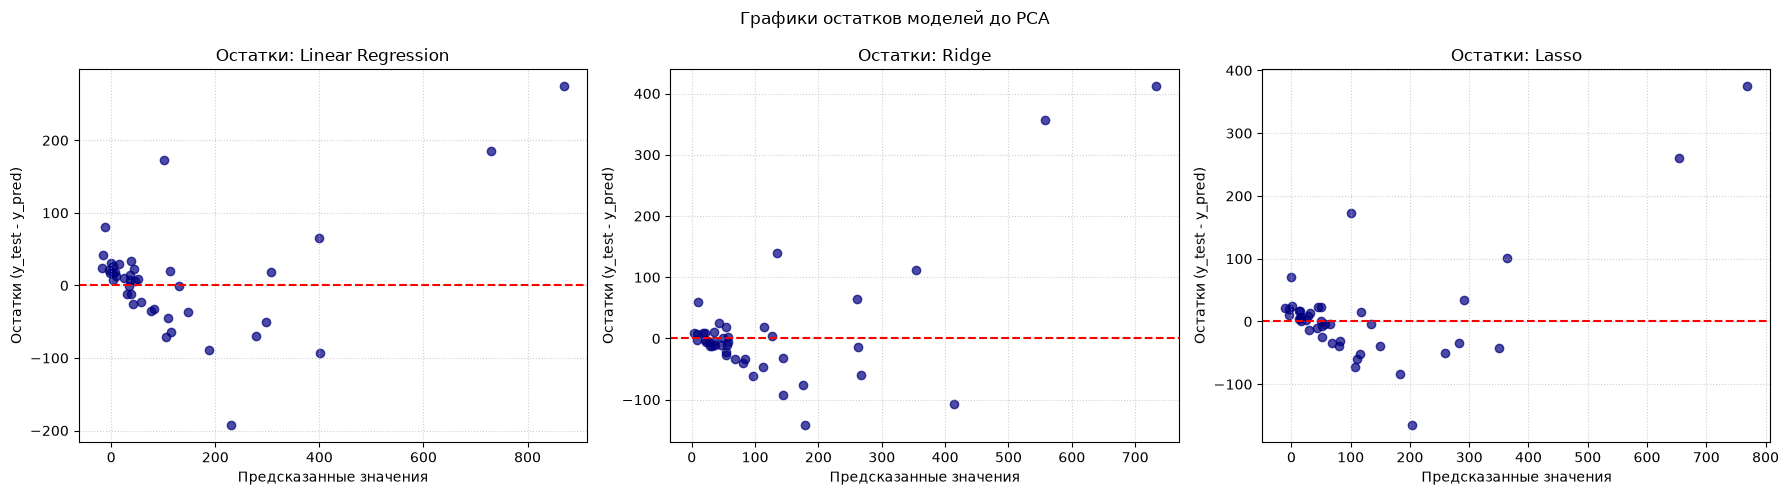

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, pipeline) in zip(axes, fitted_before.items()):
    y_pred = pipeline.predict(X_test)
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.7, color='navy')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    ax.set_title('Остатки: ' + name)
    ax.set_xlabel('Предсказанные значения')
    ax.set_ylabel('Остатки (y_test - y_pred)')
    ax.grid(True, linestyle=':', alpha=0.6)
plt.suptitle('Графики остатков моделей до PCA')
plt.tight_layout()
plt.show()

**Анализ остатков моделей до PCA:**

1. **Разброс ошибок:** остатки не распределены равномерной полосой вокруг нуля. Для некоторых высокопроизводительных систем наблюдаются крупные отклонения. Это дает основания предполагать гетероскедастичность, однако по 42 тестовым наблюдениям нельзя уверенно установить форму зависимости дисперсии.
2. **Знак остатка:** положительный остаток означает, что модель недооценила производительность; отрицательный — переоценила. Горизонтальная линия на уровне 0 соответствует точному прогнозу.
3. **Ограничения моделей:** линейная регрессия не ограничивает прогноз снизу, поэтому возможны отрицательные предсказания, хотя реальная производительность положительна. Это особенно заметно при оценке относительных ошибок малопроизводительных систем.

#### 4.3 Устранение корреляций и снижение размерности с помощью PCA

Метод главных компонент переходит от исходных признаков к их линейным комбинациям. На обучающей выборке полученные компоненты некоррелированы. Перед PCA обязательно выполняем стандартизацию. Число компонент выбираем по сохранению **не менее 90% дисперсии признаков**.

 Компонента  Доля дисперсии  Накопленная доля
          1          0.5500            0.5500
          2          0.1447            0.6948
          3          0.1244            0.8192
          4          0.0800            0.8992
          5          0.0694            0.9686
          6          0.0314            1.0000


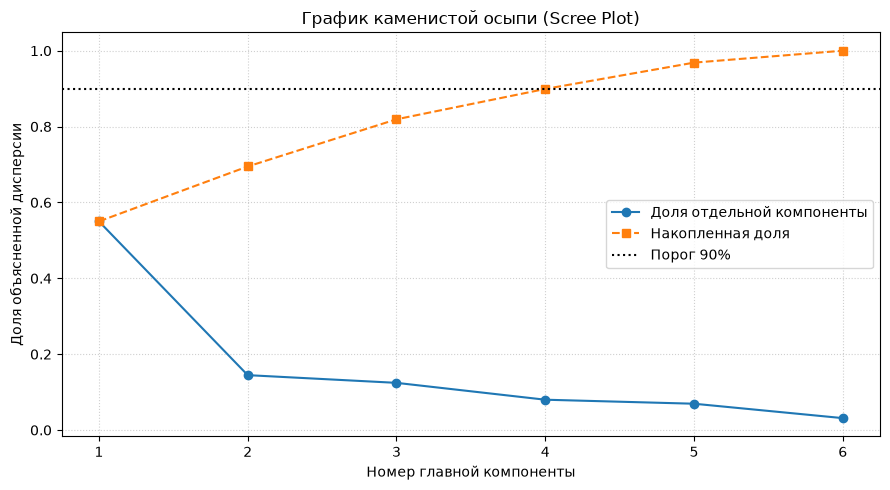

Выбрано компонент: 5
Сохранено дисперсии, %: 96.86
Размер train до / после PCA: (167, 6) (167, 5)
Размер test до / после PCA: (42, 6) (42, 5)


In [11]:
pca_full = PCA(svd_solver='full')
pca_full.fit(X_train_scaled)
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
print(pd.DataFrame({
    'Компонента': np.arange(1, len(explained_variance) + 1),
    'Доля дисперсии': explained_variance,
    'Накопленная доля': cumulative_variance
}).round(4).to_string(index=False))

plt.figure(figsize=(9, 5))
plt.plot(range(1, 7), explained_variance, marker='o', label='Доля отдельной компоненты')
plt.plot(range(1, 7), cumulative_variance, marker='s', linestyle='--',
         label='Накопленная доля')
plt.axhline(0.90, color='black', linestyle=':', label='Порог 90%')
plt.title('График каменистой осыпи (Scree Plot)')
plt.xlabel('Номер главной компоненты')
plt.ylabel('Доля объясненной дисперсии')
plt.xticks(range(1, 7))
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

pca = PCA(n_components=0.90, svd_solver='full')
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print('Выбрано компонент:', pca.n_components_)
print('Сохранено дисперсии, %:', round(pca.explained_variance_ratio_.sum() * 100, 2))
print('Размер train до / после PCA:', X_train.shape, X_train_pca.shape)
print('Размер test до / после PCA:', X_test.shape, X_test_pca.shape)

* **Распределение дисперсии:** первая главная компонента объясняет около **55,00%** дисперсии стандартизованных признаков. Значительная часть изменения характеристик оборудования описывается одним общим направлением.
* **Порог 90%:** четыре компоненты сохраняют **89,92%**, что немного ниже выбранного порога. Поэтому `PCA(n_components=0.90)` оставляет **пять компонент**, сохраняющих **96,86%** дисперсии.
* **Снижение размерности:** обучающая матрица изменилась с **167 × 6** до **167 × 5**, тестовая — с **42 × 6** до **42 × 5**. Шестая компонента отброшена. Малая дисперсия не означает, что компонента обязательно является шумом или бесполезна для предсказания `PRP`.

PCA обучался только на стандартизованном train. Тестовая выборка преобразована теми же осями с помощью `transform`, без повторного обучения. Объясненная дисперсия относится к признакам и не равна R² регрессионной модели.

Веса компонент:
         PC1    PC2    PC3    PC4    PC5
MYCT  -0.304  0.423  0.844 -0.119 -0.041
MMIN   0.439 -0.435  0.384 -0.023  0.021
MMAX   0.456 -0.291  0.222 -0.497 -0.193
CACH   0.429  0.233  0.107  0.685 -0.510
CHMIN  0.438  0.268  0.087  0.187  0.813
CHMAX  0.362  0.649 -0.268 -0.484 -0.199

Нагрузки (корреляции признаков с компонентами):
         PC1    PC2    PC3    PC4    PC5
MYCT  -0.552  0.394  0.729 -0.083 -0.027
MMIN   0.798 -0.406  0.331 -0.016  0.014
MMAX   0.828 -0.271  0.192 -0.344 -0.124
CACH   0.779  0.217  0.093  0.474 -0.329
CHMIN  0.796  0.250  0.075  0.130  0.525
CHMAX  0.658  0.604 -0.232 -0.335 -0.128


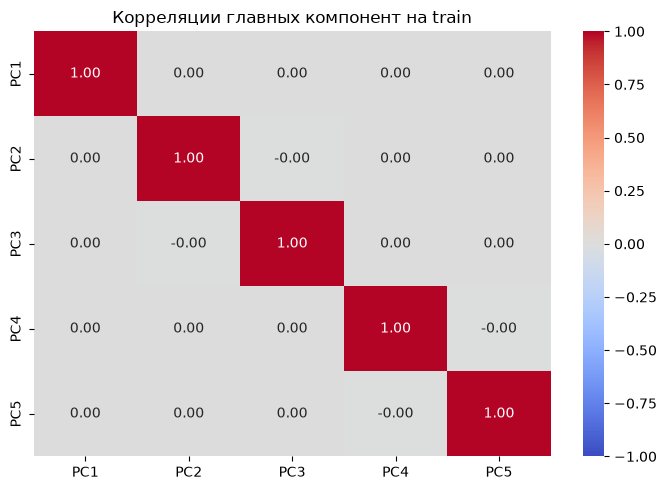

Компонента  VIF
       PC1  1.0
       PC2  1.0
       PC3  1.0
       PC4  1.0
       PC5  1.0


In [12]:
pc_names = [f'PC{i + 1}' for i in range(pca.n_components_)]

# Веса исходных стандартизованных признаков в формулах компонент
component_weights = pd.DataFrame(pca.components_.T, index=X.columns, columns=pc_names)
print('Веса компонент:')
print(component_weights.round(3))

# Корреляционные нагрузки: связь исходного признака с компонентой
joint_data = np.column_stack([X_train_scaled, X_train_pca])
loadings = pd.DataFrame(
    np.corrcoef(joint_data, rowvar=False)[:X.shape[1], X.shape[1]:],
    index=X.columns, columns=pc_names
)
print('\nНагрузки (корреляции признаков с компонентами):')
print(loadings.round(3))

pca_df = pd.DataFrame(X_train_pca, columns=pc_names)
plt.figure(figsize=(7, 5))
sns.heatmap(pca_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляции главных компонент на train')
plt.tight_layout()
plt.show()

X_pca_vif = add_constant(pca_df)
vif_pca = pd.DataFrame({
    'Компонента': pc_names,
    'VIF': [variance_inflation_factor(X_pca_vif.values, i)
            for i in range(1, X_pca_vif.shape[1])]
})
print(vif_pca.round(3).to_string(index=False))

**Нагрузки компонент:** первая компонента наиболее сильно связана с `MMAX` (**0,828**), `MMIN` (**0,798**), `CHMIN` (**0,796**) и `CACH` (**0,779**). Для второй компоненты наиболее заметна связь с `CHMAX` (**0,604** по модулю). Ее можно рассматривать как направление, дополнительно отражающее различия в каналах ввода-вывода и памяти.

Веса из `components_` задают формулы компонент, а корреляционные нагрузки показывают силу их связи с исходными признаками. Эти таблицы связаны, но их численные значения различаются. Знак компоненты условен: одновременная смена знаков ее весов и значений не меняет результат PCA.

**Проверка мультиколлинеарности:** внедиагональные корреляции компонент на train практически равны **0**, а все VIF равны **1**. Следовательно, линейные взаимосвязи между компонентами устранены. На конечной тестовой выборке корреляции не обязаны быть точно нулевыми.

#### 4.4 Повторное обучение моделей на главных компонентах

Повторим обучение трех моделей, добавив PCA между стандартизатором и регрессией. Для сопоставимости сохраняем те же train/test, пять фолдов, сетку `alpha` и правила оценки.

В кросс-валидацию передаем исходные признаки. `Pipeline` заново обучает и `StandardScaler`, и `PCA` на обучающей части каждого фолда. Порог 90% остается одинаковым, но число компонент на разных фолдах может отличаться. Подготовленные выше `X_train_pca` и `X_test_pca` служат для исследования компонент, а не для входа в кросс-валидацию.

In [13]:
results_pca = []
fitted_pca = {}
searches_pca = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.90, svd_solver='full')),
        ('model', model)
    ])
    param_grid = {} if name == 'Linear Regression' else {'model__alpha': alpha_values}
    search = GridSearchCV(
        pipeline, param_grid, cv=cv,
        scoring='neg_root_mean_squared_error', refit=True
    )
    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    fitted_pca[name] = best_model
    searches_pca[name] = search

    y_pred_train = best_model.predict(X_train)
    y_pred = best_model.predict(X_test)
    train_metrics = calculate_metrics(y_train, y_pred_train)
    test_metrics = calculate_metrics(y_test, y_pred)

    row = {
        'Модель': name,
        'alpha': search.best_params_.get('model__alpha', np.nan),
        'CV RMSE': -search.best_score_,
        'CV std': search.cv_results_['std_test_score'][search.best_index_]
    }
    for metric in train_metrics:
        row[metric + ' train'] = train_metrics[metric]
        row[metric + ' test'] = test_metrics[metric]
    results_pca.append(row)

df_results_pca = pd.DataFrame(results_pca)
print(df_results_pca.round(3).to_string(index=False))

           Модель  alpha  CV RMSE  CV std  RMSE train  RMSE test  R² train  R² test  MAPE (%) train  MAPE (%) test
Linear Regression    NaN   68.634  32.881      55.943     73.152     0.837    0.895          68.936         78.878
            Ridge  100.0   66.309  38.219      62.506     97.145     0.797    0.815          44.472         55.855
            Lasso   10.0   65.222  32.915      61.222     90.572     0.805    0.839          55.114         61.182


После добавления PCA все модели заново обучены и проверены на тех же 42 тестовых наблюдениях. Для Ridge снова выбрано `alpha=100`, для Lasso — `alpha=10`. В каждой итоговой модели PCA оставил пять компонент; внутри кросс-валидации число компонент определяется отдельно по обучающей части фолда.

Наименьший средний CV RMSE среди вариантов с PCA получил **Lasso: 65,22**. Однако на тестовой выборке наименьший RMSE у **линейной регрессии: 73,15**, R² равен **0,895**. Это показывает, что ранжирование на кросс-валидации и на одном тестовом разбиении может отличаться. Тестовые результаты не используем для повторного подбора `alpha`.

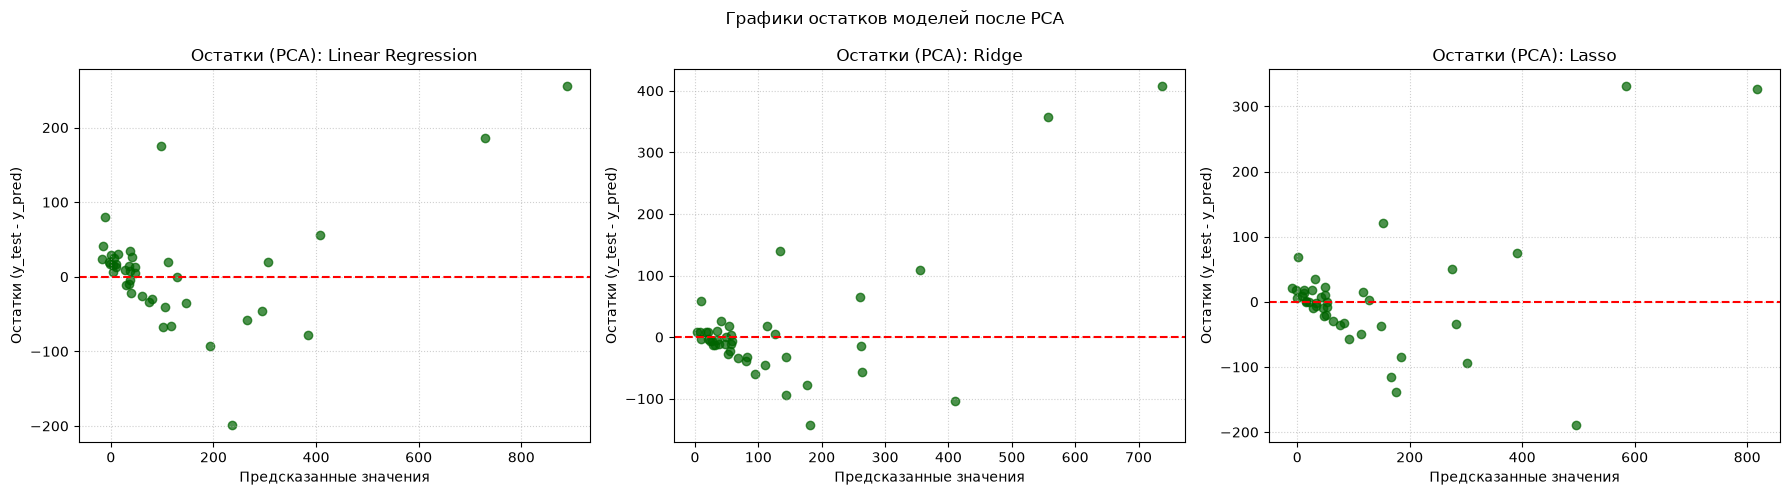

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, pipeline) in zip(axes, fitted_pca.items()):
    y_pred_pca = pipeline.predict(X_test)
    residuals = y_test - y_pred_pca
    ax.scatter(y_pred_pca, residuals, alpha=0.7, color='darkgreen')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    ax.set_title('Остатки (PCA): ' + name)
    ax.set_xlabel('Предсказанные значения')
    ax.set_ylabel('Остатки (y_test - y_pred)')
    ax.grid(True, linestyle=':', alpha=0.6)
plt.suptitle('Графики остатков моделей после PCA')
plt.tight_layout()
plt.show()

После PCA крупные остатки сохраняются. Переход к некоррелированным компонентам сам по себе не устраняет возможную гетероскедастичность и не гарантирует улучшение прогноза. По графикам не видно оснований утверждать, что разброс ошибок стал постоянным.

Поэтому качество оцениваем по таблицам метрик, а устранение корреляций — отдельно по матрице компонент и VIF. Это разные результаты работы.

#### 4.5 Итоговое сравнение моделей

Сравнение на одних и тех же тестовых наблюдениях:
           Модель  RMSE test до PCA  R² test до PCA  MAPE (%) test до PCA  RMSE test после PCA  R² test после PCA  MAPE (%) test после PCA
Linear Regression            75.054           0.889                80.269               73.152              0.895                   78.878
            Ridge            97.668           0.813                55.709               97.145              0.815                   55.855
            Lasso            86.673           0.852                64.188               90.572              0.839                   61.182


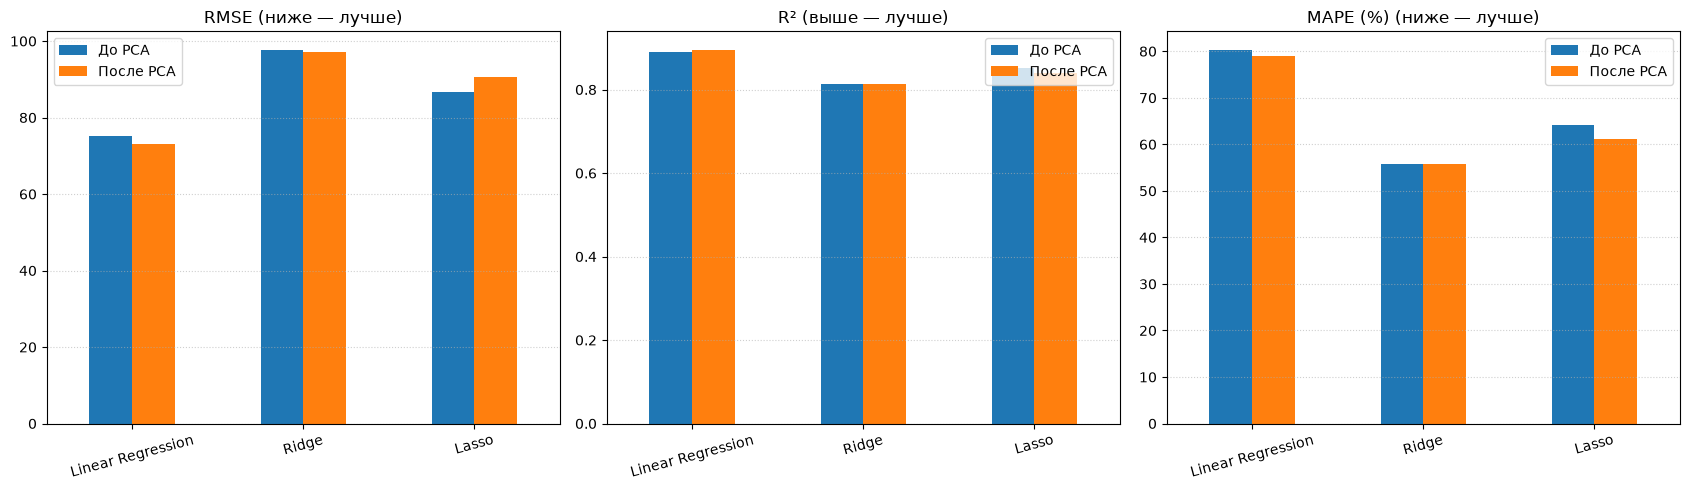

Лучшая модель по CV RMSE:
Модель          Lasso
Признаки          PCA
alpha            10.0
CV RMSE      65.22198
CV std      32.915049
Name: 5, dtype: object


In [15]:
metric_columns = ['Модель', 'RMSE test', 'R² test', 'MAPE (%) test']
df_comparison = pd.merge(
    df_results_before[metric_columns], df_results_pca[metric_columns],
    on='Модель', suffixes=(' до PCA', ' после PCA')
)
print('Сравнение на одних и тех же тестовых наблюдениях:')
print(df_comparison.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, metric in zip(axes, ['RMSE', 'R²', 'MAPE (%)']):
    comparison_plot = pd.DataFrame({
        'До PCA': df_results_before.set_index('Модель')[metric + ' test'],
        'После PCA': df_results_pca.set_index('Модель')[metric + ' test']
    })
    comparison_plot.plot.bar(ax=ax, rot=15)
    ax.set_title(metric + (' (выше — лучше)' if metric == 'R²' else ' (ниже — лучше)'))
    ax.set_xlabel('')
    ax.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Выбор только по CV на train; test не участвует в выборе
all_results = pd.concat([
    df_results_before.assign(Признаки='Исходные'),
    df_results_pca.assign(Признаки='PCA')
], ignore_index=True)
best_row = all_results.loc[all_results['CV RMSE'].idxmin()]
print('Лучшая модель по CV RMSE:')
print(best_row[['Модель', 'Признаки', 'alpha', 'CV RMSE', 'CV std']])

1. **Линейная регрессия:** после PCA RMSE снизился с **75,05 до 73,15**, R² вырос с **0,889 до 0,895**, MAPE уменьшилась с **80,27% до 78,88%**. Для этой модели все три тестовые метрики немного улучшились.
2. **Ridge:** RMSE уменьшился с **97,67 до 97,15**, R² вырос с **0,813 до 0,815**, но MAPE немного увеличилась с **55,71% до 55,85%**. Изменения небольшие и разнонаправленные.
3. **Lasso:** RMSE вырос с **86,67 до 90,57**, R² снизился с **0,852 до 0,839**, а MAPE улучшилась с **64,19% до 61,18%**. Снижение относительной ошибки сопровождается увеличением среднеквадратичной ошибки.

**Выбор модели:** по заранее выбранному критерию минимального CV RMSE лучшим оказался **Lasso с PCA, alpha=10**: средняя ошибка **65,22**, стандартное отклонение по фолдам **32,92**. Разница с Ridge + PCA (CV RMSE **66,31**) невелика по сравнению с разбросом, поэтому уверенное превосходство не установлено. На данном тестовом разбиении линейная регрессия с PCA имеет лучший RMSE и R², а Ridge без PCA — лучшую MAPE. Это описание тестовых результатов, а не смена правила выбора модели.

**Общий результат сравнения:** PCA устранил корреляции между признаками и уменьшил их количество с шести до пяти. При этом улучшение качества зависит от модели и выбранной метрики. Утверждать, что PCA обязательно убирает шум, предотвращает переобучение или улучшает все прогнозы, по этим результатам нельзя.

### 5 Заключение

В ходе выполнения лабораторной работы было проведено исследование и построение регрессионных моделей для предсказания опубликованной относительной производительности компьютеров (целевая переменная `PRP`).

**Основные итоги работы:**

1. **Подготовка и анализ данных:** исследованы 209 наблюдений, пропусков и дубликатов не обнаружено. Категориальные поля и готовая оценка `ERP` исключены из признаков. Распределения имеют выраженную правую асимметрию, статистически необычные наблюдения сохранены. Признаки памяти заметно коррелируют, но VIF **1,20–3,27** не подтверждает сильную мультиколлинеарность.
2. **Первичное моделирование:** построены Linear Regression, Ridge и Lasso. На исходных признаках линейная регрессия показала **R² ≈ 0,889** и **RMSE ≈ 75,05**, однако MAPE осталась высокой (**80,27%**). Для Ridge и Lasso параметр регуляризации выбран на пятикратной кросс-валидации. Предобработка выполнялась внутри каждого фолда, без использования его проверочной части и тестовой выборки при обучении преобразований.
3. **Применение PCA:** после стандартизации выбран порог 90% объясненной дисперсии. Для его достижения потребовалось **пять компонент**, сохраняющих **96,86%** дисперсии. Корреляции между компонентами на train близки к нулю, а VIF равны 1.
4. **Оценка итоговых результатов:** у линейной регрессии PCA немного улучшил все три тестовые метрики (**RMSE ≈ 73,15; R² ≈ 0,895; MAPE ≈ 78,88%**). Для Ridge и Lasso изменения смешанные. По среднему CV RMSE выбран Lasso с PCA, но большой разброс по фолдам не позволяет утверждать, что его преимущество устойчиво. Графики остатков дают основания предполагать неоднородность разброса ошибок и после PCA.

**Общий вывод:** метод главных компонент позволил получить некоррелированные признаки и немного снизить размерность. Его применение оказалось полезным для части показателей, но не стало универсальным способом повысить точность. Высокая относительная ошибка и небольшая выборка ограничивают надежность прогнозов, поэтому результаты следует оценивать одновременно по нескольким метрикам.